In [1]:
import pandas as pd
olx=pd.read_csv("../data/processed/olx_cleaned.csv")
ebay=pd.read_csv("../data/processed/ebay_cleaned.csv") 
used=pd.read_csv("../data/processed/used_devices_cleaned.csv")

In [4]:
print(olx['price'].dtype)
print(olx['price'].head())
print(olx['price'].isna().sum())

str
0    Rs 115,000
1      Rs 9,999
2    Rs 122,000
3    Rs 215,000
4     Rs 18,499
Name: price, dtype: str
0


In [5]:
olx['price']=(olx['price'].str.replace('Rs','').str.replace(',','').str.strip())
olx['price'] = pd.to_numeric(olx['price'], errors='coerce')

In [7]:
print(olx['price'].dtype)
print(olx['price'].head())

float64
0    115000.0
1      9999.0
2    122000.0
3    215000.0
4     18499.0
Name: price, dtype: float64


In [8]:
def price_category(price):
    if price < 10000:
        return 'Budget'
    elif price < 30000:
        return 'Mid-Range'
    else:
        return 'Premium'

olx['price_category'] = olx['price'].apply(price_category)

In [9]:
olx['price_category'].value_counts()


price_category
Premium      2322
Budget       1027
Mid-Range     582
Name: count, dtype: int64

In [10]:
def age_group(days_used):
    if days_used < 365:
        return 'Less than a Year'
    elif days_used < 730:
        return '1-2 Years'
    else:
        return 'More than 2 Years'

used['age_group'] = used['days_used'].apply(age_group)

In [11]:
used['age_group'].value_counts()

age_group
More than 2 Years    1492
1-2 Years            1454
Less than a Year      508
Name: count, dtype: int64

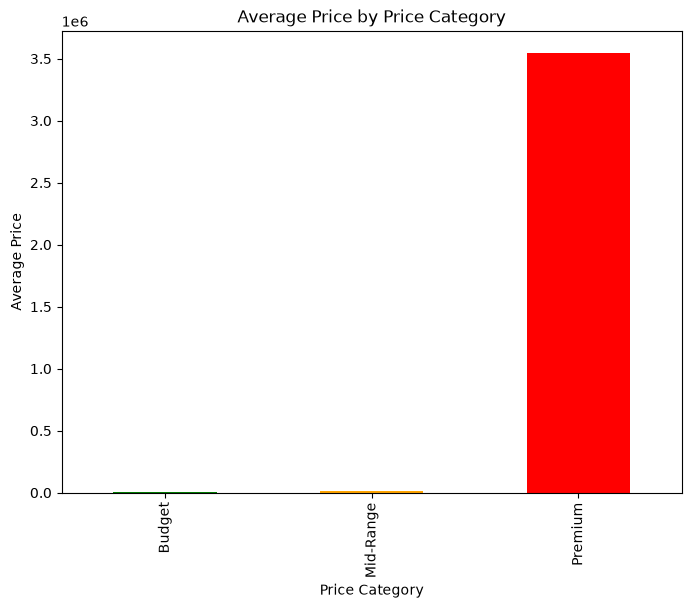

In [14]:
import matplotlib.pyplot as plt
avg_price=olx.groupby('price_category')['price'].mean()
plt.figure(figsize=(8,6))
avg_price.plot(kind='bar', color=['green', 'orange', 'red'])
plt.title('Average Price by Price Category')
plt.xlabel('Price Category')
plt.ylabel('Average Price')
plt.show()

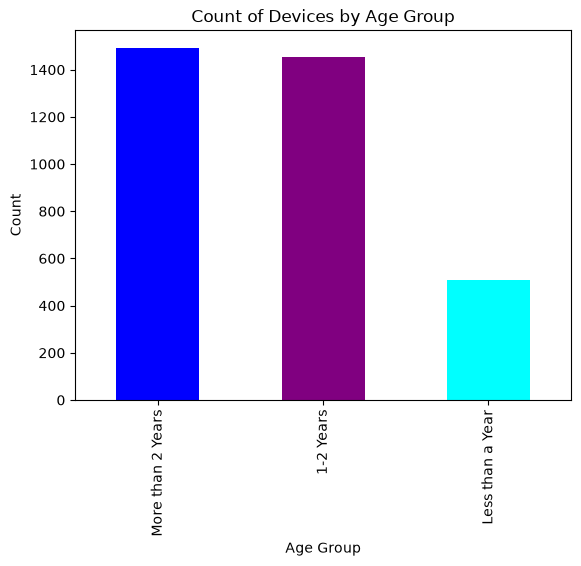

In [15]:
used['age_group'].value_counts().plot(kind='bar', color=['blue', 'purple', 'cyan'])
plt.title('Count of Devices by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.show()

In [16]:
olx.to_csv("../data/processed/olx_featured.csv", index=False)
used.to_csv("../data/processed/used_devices_featured.csv", index=False)

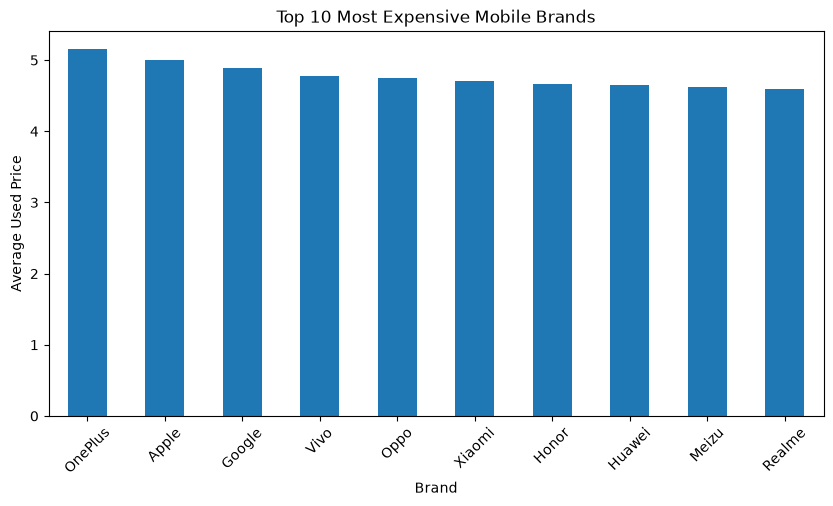

In [17]:
top_price = (
    used.groupby("brand_name")["normalized_used_price"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)
plt.figure(figsize=(10,5))
top_price.plot(kind="bar")
plt.title("Top 10 Most Expensive Mobile Brands")
plt.xlabel("Brand")
plt.ylabel("Average Used Price")
plt.xticks(rotation=45)
plt.show()

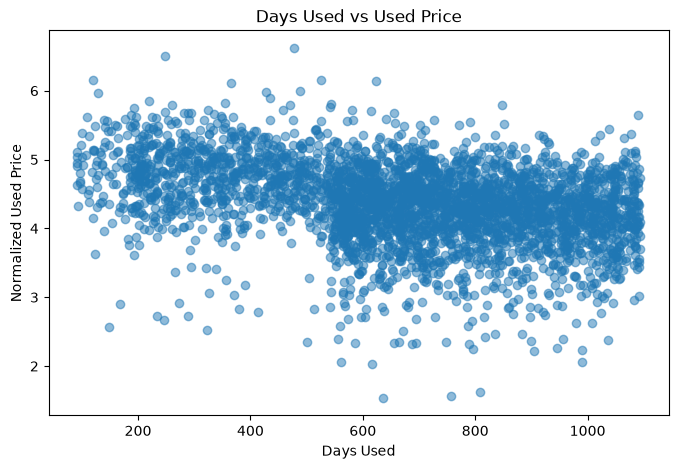

In [18]:
plt.figure(figsize=(8,5))
plt.scatter(
    used["days_used"],
    used["normalized_used_price"],
    alpha=0.5
)
plt.title("Days Used vs Used Price")
plt.xlabel("Days Used")
plt.ylabel("Normalized Used Price")
plt.show()

Index(['Unnamed: 0', 'categoryName', 'userName', 'dateJoined', 'location',
       'price', 'title', 'brand', 'condition', 'description', 'adId',
       'price_category'],
      dtype='str')


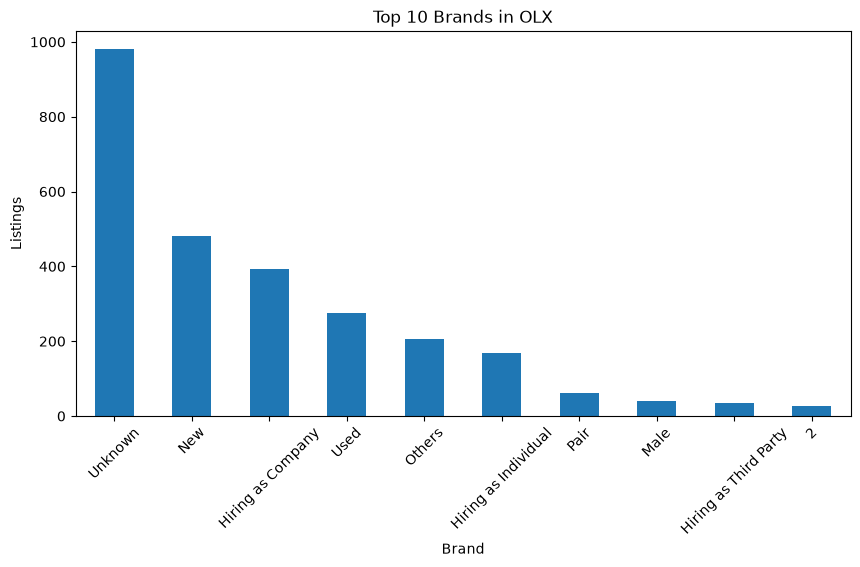

In [19]:
print(olx.columns)

top_brand = olx["brand"].value_counts().head(10)
plt.figure(figsize=(10,5))
top_brand.plot(kind="bar")
plt.title("Top 10 Brands in OLX")
plt.xlabel("Brand")
plt.ylabel("Listings")
plt.xticks(rotation=45)
plt.show()

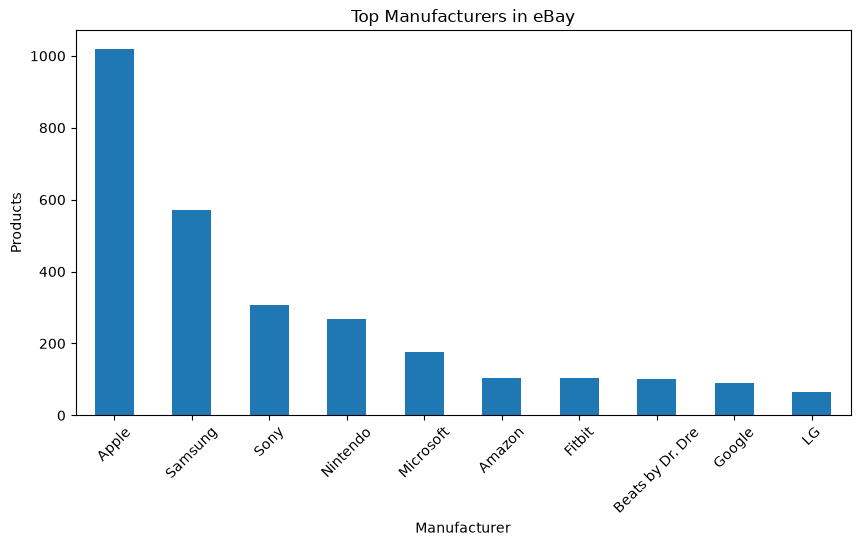

In [20]:
top_manu = ebay["Manufacturer"].value_counts().head(10)
plt.figure(figsize=(10,5))
top_manu.plot(kind="bar")
plt.title("Top Manufacturers in eBay")
plt.xlabel("Manufacturer")
plt.ylabel("Products")
plt.xticks(rotation=45)
plt.show()

In [23]:
ebay['Price']=(ebay['Price'].astype(str).str.replace('$','').str.replace(',','').str.strip())
ebay['Price'] = pd.to_numeric(ebay['Price'], errors='coerce')

In [24]:
summary = {
    "OLX Average Price": olx["price"].mean(),
    "eBay Average Price": ebay["Price"].mean(),
    "Used Average Price": used["normalized_used_price"].mean(),

    "OLX Listings": len(olx),
    "eBay Listings": len(ebay),
    "Used Devices": len(used)
}
print(summary)

{'OLX Average Price': np.float64(1483060.2472806382), 'eBay Average Price': np.float64(150.37038499449181), 'Used Average Price': np.float64(4.364712079133227), 'OLX Listings': 3931, 'eBay Listings': 17577, 'Used Devices': 3454}


In [25]:
insights = pd.DataFrame(summary.items(), columns=["Metric", "Value"])
insights.to_csv("../data/processed/project_insights.csv", index=False)